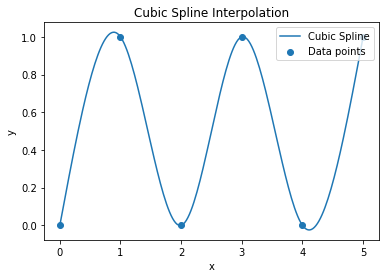

In [1]:
# Used ChatGPT for plotting, help with comments, and term sorting correction in spline evaluation function.

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Builds the tridiagonal system (A, B, C, D) for cubic spline
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients 
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side

    # Populare the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]                           # Subdiagonal
        B[i - 1] = 2 * (h[i - 1] + h[i])              # Main diagonal
        C[i - 1] = h[i]                               # Super diagonal
        # Change in slope between intervals
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] 
                        - (y[i] - y[i - 1]) / h[i - 1]) #Right-hand side vector

    return A, B, C, D


# Solves tridiagonal system using Thomas Algorithm
def thomas_algorithm(a, b, c, d):
    n = len(b)

    # Forward elimination (makes matrix upper triangular)
    for i in range(1, n):
        w = a[i - 1] / b[i - 1]
        b[i] = b[i] - w * c[i - 1]
        d[i] = d[i] - w * d[i - 1]

    # Back substitution (solve for unknowns)
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / b[i]

    return x


# Evaluates the spline at new x values
def evaluate_spline(x, y, M, x_eval):
    n = len(x)
    h = np.diff(x)
    y_eval = []

    for xe in x_eval:
        # Find which interval xe belongs to
        i = np.searchsorted(x, xe) - 1
        if i == n - 1:
            i -= 1
        if i < 0:
            i = 0

        hi = h[i]

        # Cubic spline formula (4 terms)
        term1 = M[i] * (x[i+1] - xe)**3 / (6 * hi)
        term2 = M[i+1] * (xe - x[i])**3 / (6 * hi)
        term3 = (y[i] - M[i] * hi**2 / 6) * (x[i+1] - xe) / hi
        term4 = (y[i+1] - M[i+1] * hi**2 / 6) * (xe - x[i]) / hi

        # Add result
        y_eval.append(term1 + term2 + term3 + term4)

    return np.array(y_eval)


# Given data points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

#Build tridiagonal system
A, B, C, D = setup_tridiagonal_matrix(x, y)

#Solve for second derivatives (M values)
M_internal = thomas_algorithm(A.copy(), B.copy(), C.copy(), D.copy())

#natural boundary conditions (endpoints = 0)
M = np.zeros(len(x))
M[1:-1] = M_internal

# axis and spline function
x_dense = np.linspace(0, 5, 200)
y_dense = evaluate_spline(x, y, M, x_dense)

#Plot points and spline curve
plt.scatter(x, y, label="Data points")
plt.plot(x_dense, y_dense, label="Cubic Spline")
plt.title("Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()